# DeepWeeds — Chặng 1: chuẩn bị và EDA
Gắn hai dataset: ảnh DeepWeeds và kaggle_stage1_code.zip. Chạy lần lượt từ trên xuống.
Chặng này không train và không tính metric test. CPU đủ cho EDA; GPU chỉ cần kiểm tra sẵn.
Kết quả tải về: `/kaggle/working/stage1_results.zip`.


In [1]:
import importlib.util
import subprocess
import sys
packages = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib", "PIL": "pillow"}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
import torch
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPUs:", [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
if not torch.cuda.is_available():
    print("CPU vẫn chạy được chặng 1. Cần bật GPU trước chặng 2.")


PyTorch: 2.11.0+cu128
CUDA: True
GPUs: ['Tesla T4', 'Tesla T4']


In [2]:
from pathlib import Path
import shutil
import zipfile
INPUT = Path("/kaggle/input")
WORK = Path("/kaggle/working/deepweeds_stage1")
WORK.mkdir(parents=True, exist_ok=True)
sources = list(INPUT.rglob("stage1.py"))
archives = list(INPUT.rglob("kaggle_stage1_code.zip"))
if len(sources) == 1:
    source = sources[0].parent.parent
    shutil.copytree(source, WORK, dirs_exist_ok=True)
elif not sources and len(archives) == 1:
    with zipfile.ZipFile(archives[0]) as archive:
        archive.extractall(WORK)
else:
    raise RuntimeError(f"Cần đúng một nguồn code. Tìm thấy: {sources}, {archives}")
assert (WORK / "code/stage1.py").is_file()
sys.path.insert(0, str(WORK / "code"))
from stage1 import prepare_labels, run
print("Code:", WORK)


Code: /kaggle/working/deepweeds_stage1


In [3]:
image_zips = list(INPUT.rglob("images.zip"))
image_roots = sorted({p.parent for p in INPUT.rglob("20160928-140314-0.jpg")})
if len(image_zips) == 1:
    IMAGES = image_zips[0]
elif not image_zips and len(image_roots) == 1:
    IMAGES = image_roots[0]
else:
    raise RuntimeError(f"Cần đúng một nguồn ảnh. ZIP: {image_zips}; thư mục: {image_roots}")
LABELS = prepare_labels(WORK / "labels")
OUT = WORK / "eda/kaggle"
print("Images:", IMAGES)
print("Labels:", LABELS)


Images: /kaggle/input/datasets/luuquangkhai/data-labd2/images
Labels: /kaggle/working/deepweeds_stage1/labels


## Kiểm tra và EDA
Cell tiếp theo đọc toàn bộ ảnh để kiểm tra hỏng file, đối chiếu nhãn, kiểm tra split.
Thống kê test chỉ dùng kiểm tra tính toàn vẹn dữ liệu. 27 ảnh minh họa lấy từ train.
Nếu kiểm tra báo lỗi, dừng tại đây và gửi traceback.


In [4]:
summary = run(IMAGES, LABELS, OUT)
assert summary["status"] == "PASS"
with (OUT / "pip-freeze.txt").open("w") as f:
    subprocess.run([sys.executable, "-m", "pip", "freeze"], stdout=f, check=True)


Decoded 5000/17509 images
Decoded 10000/17509 images
Decoded 15000/17509 images
              species  train   val  test  total  master_total
label                                                        
0        Chinee apple    675   225   226   1126          1125
1             Lantana    637   213   213   1063          1064
2         Parkinsonia    618   206   207   1031          1031
3          Parthenium    613   204   205   1022          1022
4      Prickly acacia    637   212   213   1062          1062
5         Rubber vine    605   202   202   1009          1009
6           Siam weed    644   215   215   1074          1074
7          Snake weed    609   203   204   1016          1016
8            Negative   5463  1821  1822   9106          9106
{
  "status": "PASS",
  "fold": 0,
  "seed_for_samples": 0,
  "label_discrepancies": [
    {
      "split": "train",
      "Filename": "20170714-110407-3.jpg",
      "split_label": 0,
      "master_label": 1
    }
  ],
  "label_policy": "

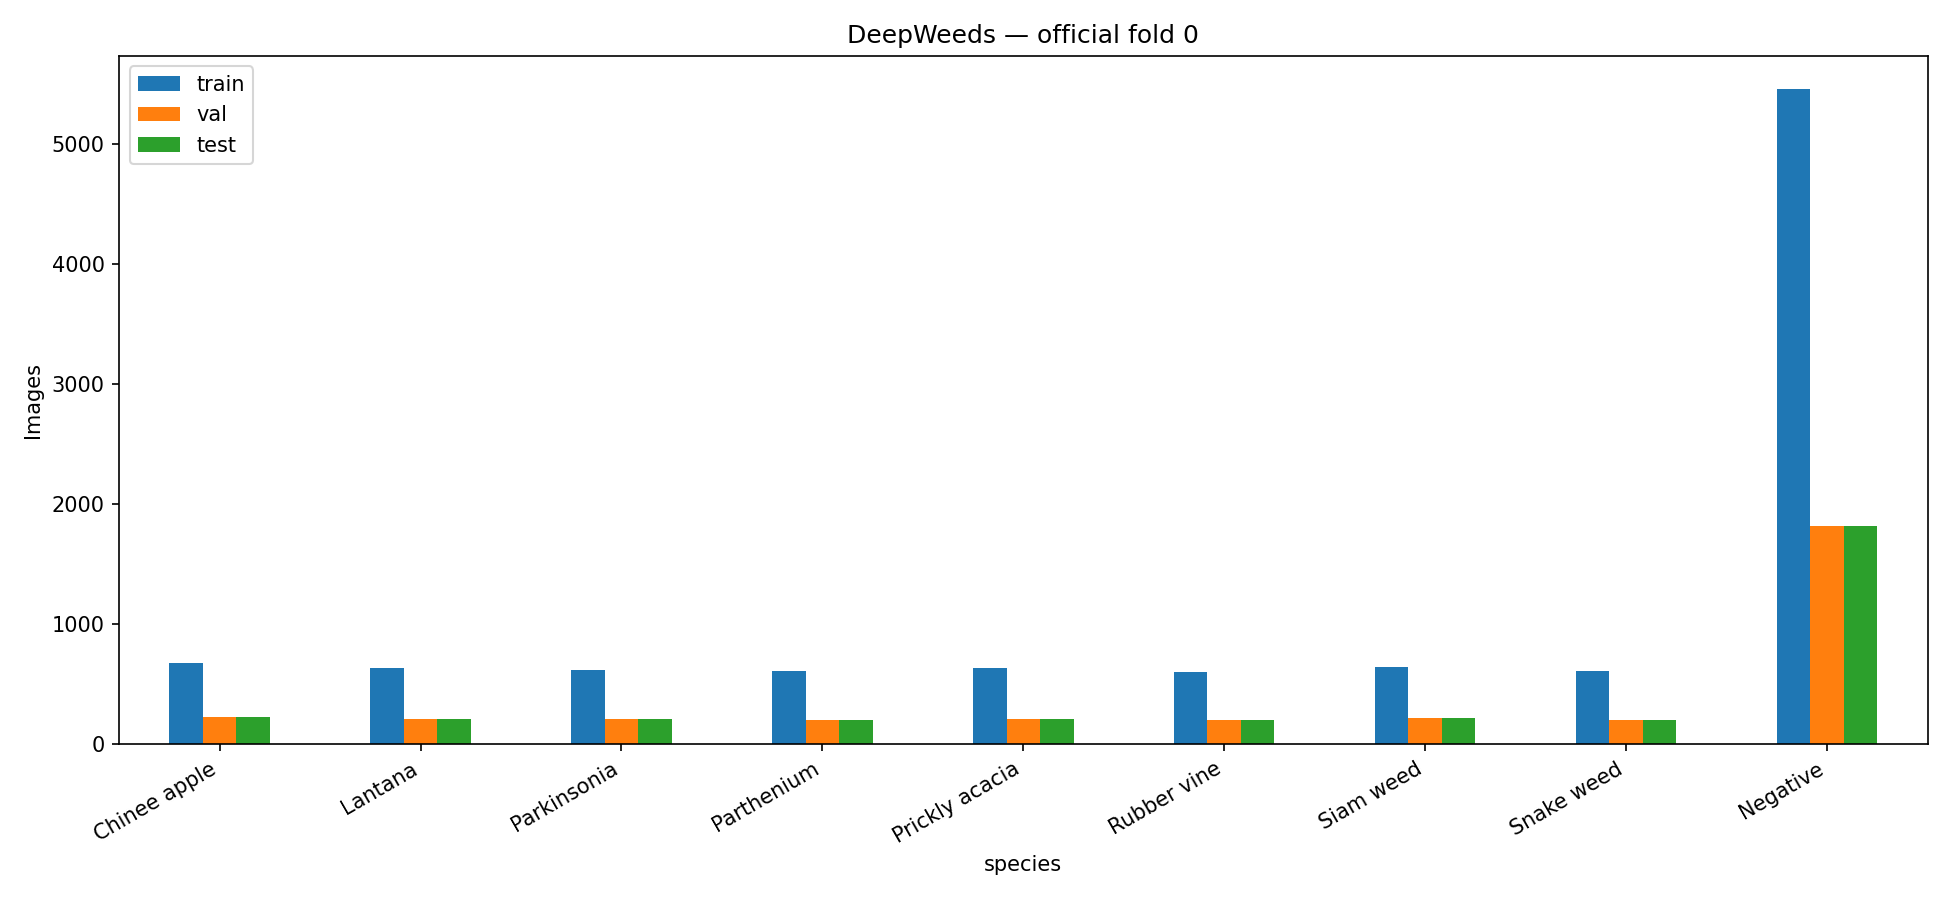

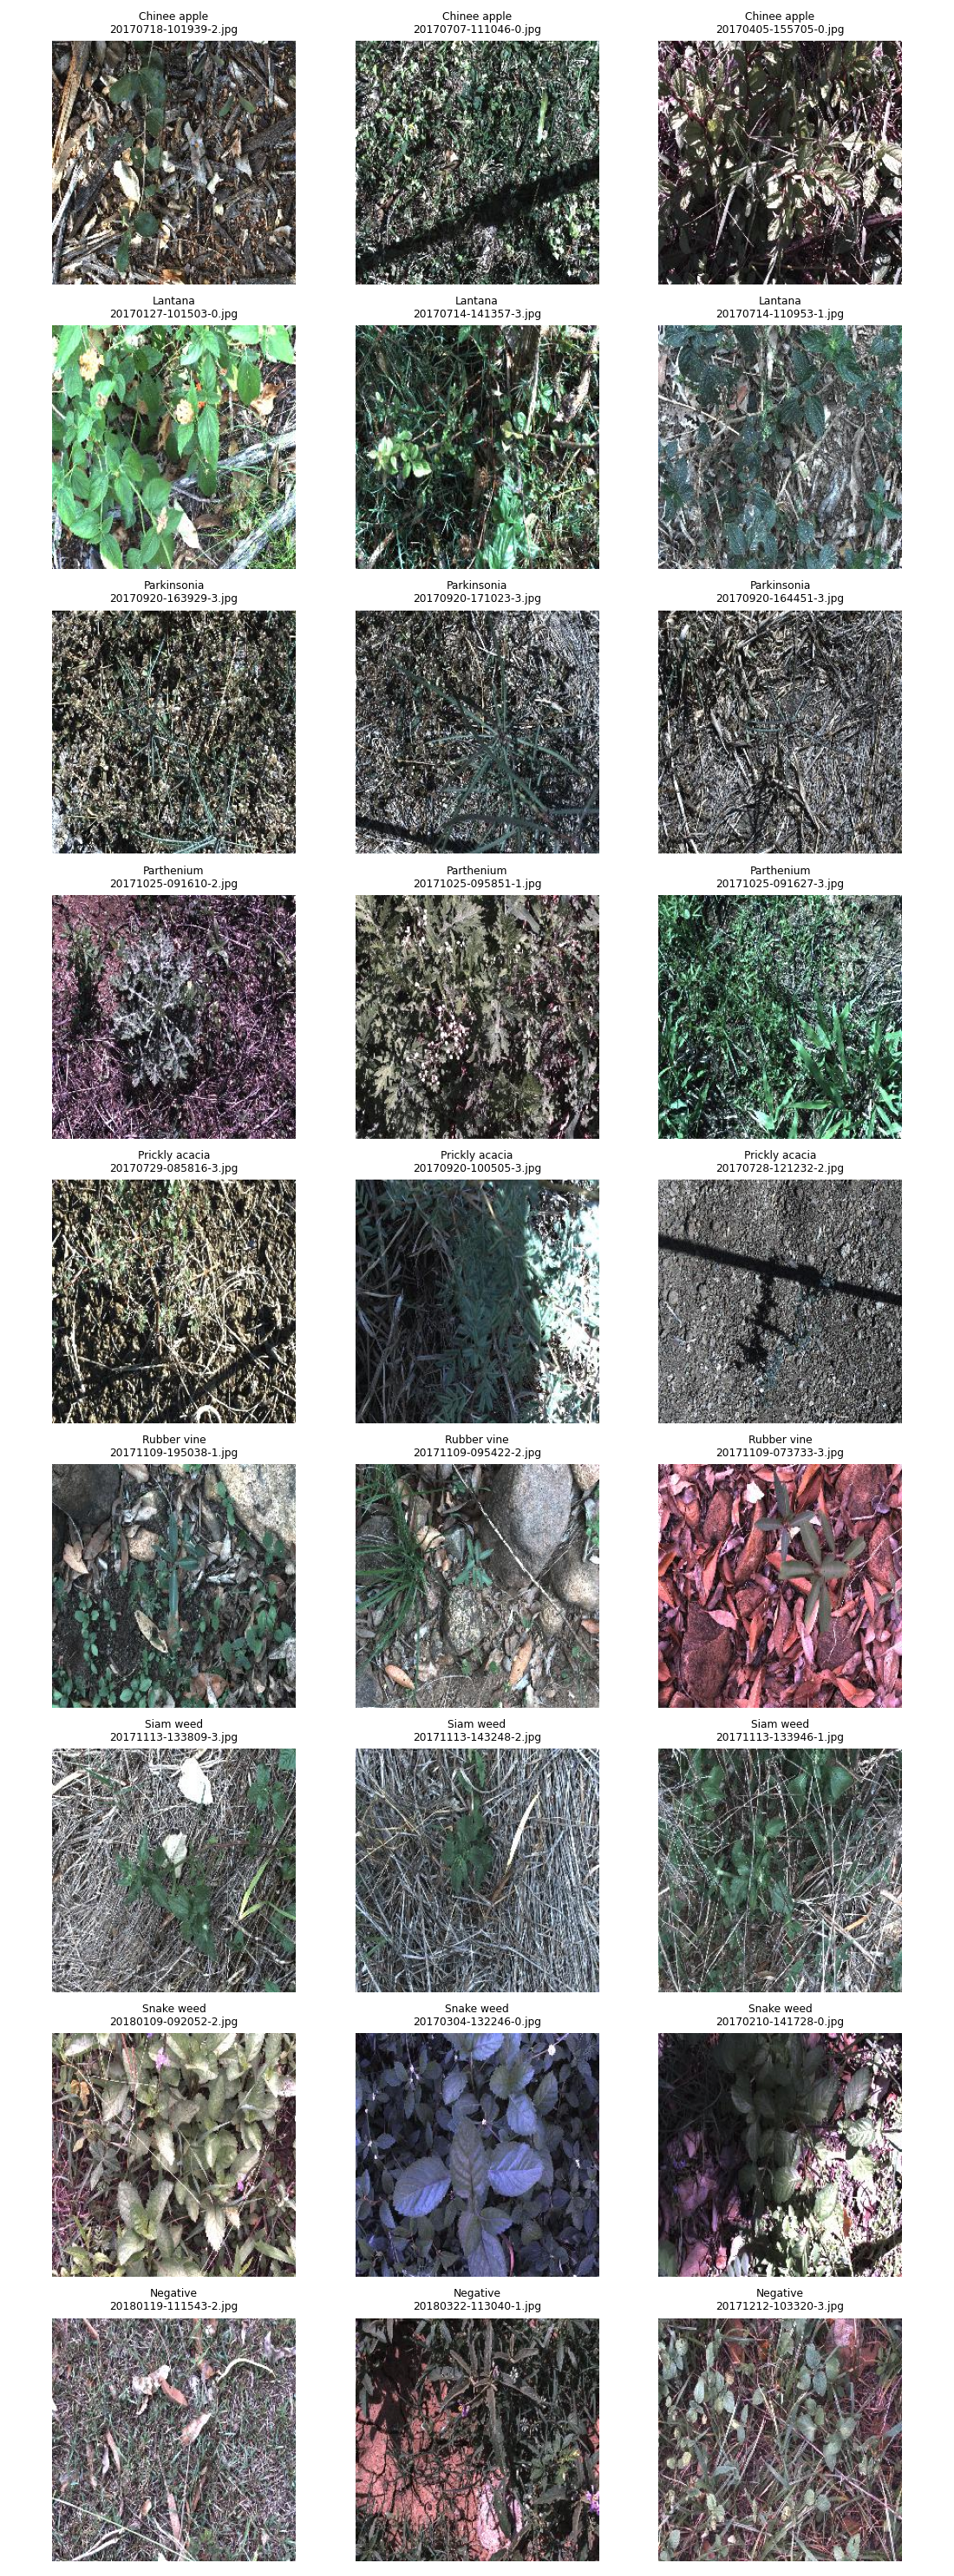

In [5]:
from IPython.display import display, Image
display(Image(filename=str(OUT / "class_distribution.png")))
display(Image(filename=str(OUT / "train_samples.png")))


In [6]:
archive_path = Path("/kaggle/working/stage1_results.zip")
with zipfile.ZipFile(archive_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for p in sorted(OUT.rglob("*")):
        if p.is_file():
            archive.write(p, "eda/" + p.relative_to(OUT).as_posix())
    for p in sorted(LABELS.glob("*.csv")):
        archive.write(p, "labels/" + p.name)
print("PASS — tải file này về và gửi lại:", archive_path)


PASS — tải file này về và gửi lại: /kaggle/working/stage1_results.zip
